# Load and Plot SWOT EXPERT Data

Authors: Lexi Jones-Kellett, Sarah Lang, Tasha Snow

- Showing the SWOT data compared to OSCAR
- Calculated SWOT velocities and streamlines from L2
- Visualize eddy contour detected by AVISO eddy tracking

Note: Please see two boxes that beging with "To do" below.

In [1]:
import earthaccess,csv
import xarray as xr
from xarray.backends.api import open_datatree
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
from scipy.ndimage import generic_filter
from scipy.ndimage import gaussian_filter
from scipy.interpolate import griddata

In [2]:
# Set default fontsizes for plots
fontsize = 18

plt.rc('font', size=fontsize)          # controls default text sizes
plt.rc('axes', titlesize=fontsize)     # fontsize of the axes title
plt.rc('axes', labelsize=fontsize)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=fontsize)    # fontsize of the tick labels
plt.rc('ytick', labelsize=fontsize)    # fontsize of the tick labels
plt.rc('legend', fontsize=fontsize)    # legend fontsize
plt.rc('figure', titlesize=fontsize)  # fontsize of the figure title

### To do: Below, add date requested in following formats. Input correct AVISO data for eddy of interest.

In [3]:
date_requested = '20240508'
pacedate="2024-05-08"

In [4]:
aviso_ds = xr.open_dataset('data/eddy_trajectories/Edward_Eddy_trajectory_nrt_3.2exp_cyclonic_20180101_20240723.nc')

### To do: Add in low-res altimeter data (SSH)

NOTE: I can't find any usable SSH products in EarthAccess. Downloaded data from CMEMS here: https://data.marine.copernicus.eu/product/SEALEVEL_GLO_PHY_L4_NRT_008_046/files?subdataset=cmems_obs-sl_glo_phy-ssh_nrt_allsat-l4-duacs-0.25deg_P1D_202311&path=SEALEVEL_GLO_PHY_L4_NRT_008_046%2Fcmems_obs-sl_glo_phy-ssh_nrt_allsat-l4-duacs-0.25deg_P1D_202311%2F2024%2F05%2F

In [5]:
CMEMS_dir = 'data/CMEMS_data/'
CMEMS_day = xr.open_dataset(CMEMS_dir + 'nrt_global_allsat_phy_l4_20240508_20240514.nc')
CMEMS_day

<xarray.Dataset> Size: 83MB
Dimensions:    (time: 1, latitude: 720, nv: 2, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 8B 2024-05-08
  * latitude   (latitude) float32 3kB -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * longitude  (longitude) float32 6kB -179.9 -179.6 -179.4 ... 179.6 179.9
  * nv         (nv) int32 8B 0 1
Data variables: (12/13)
    crs        int32 4B ...
    lat_bnds   (latitude, nv) float32 6kB ...
    lon_bnds   (longitude, nv) float32 12kB ...
    sla        (time, latitude, longitude) float64 8MB ...
    err_sla    (time, latitude, longitude) float64 8MB ...
    ugosa      (time, latitude, longitude) float64 8MB ...
    ...         ...
    vgosa      (time, latitude, longitude) float64 8MB ...
    err_vgosa  (time, latitude, longitude) float64 8MB ...
    adt        (time, latitude, longitude) float64 8MB ...
    ugos       (time, latitude, longitude) float64 8MB ...
    vgos       (time, latitude, longitude) float64 8MB ...
    flag_ice   (time, latitude, longitude) float64 8MB ...
Attributes: (12/44)
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Grid
    comment:                         Sea Surface Height measured by Altimetry...
    contact:                         servicedesk.cmems@mercator-ocean.eu
    creator_email:                   servicedesk.cmems@mercator-ocean.eu
    ...                              ...
    summary:                         SSALTO/DUACS Near-Real-Time Level-4 sea ...
    time_coverage_duration:          P1D
    time_coverage_end:               2024-05-08T12:00:00Z
    time_coverage_resolution:        P1D
    time_coverage_start:             2024-05-07T12:00:00Z
    title:                           NRT merged all satellites Global Ocean G...

In [6]:
dates = [i for i in aviso_ds.time.values] # these are sorted already
print(min(dates))
print(max(dates)) # still existed at the end of the dataset
tminny=str(min(dates))
tminny=tminny[0:10]
tmaxxy=str(max(dates))
tmaxxy=tmaxxy[0:10]
tmin,tmax = tminny,tmaxxy
center_lats = [i for i in aviso_ds.latitude.values]
center_lons = [i for i in aviso_ds.longitude.values]
print(len(center_lats))
print(min(center_lats))
print(max(center_lats))
print(min(center_lons)-360)
print(max(center_lons)-360)
#Define box based on eddy
latmin,latmax = min(center_lats)-2,max(center_lats)+2
lonmin,lonmax = min(center_lons)-360-2,max(center_lons)-360+2

2023-12-14T00:00:00.000000000
2024-07-23T00:00:00.000000000
223
35.502697
36.847385
-71.77410888671875
-67.88714599609375


Log into earthaccess

In [7]:
auth = earthaccess.login(persist=True)

Check the names of the SWOT datasets available on earthaccess

In [8]:
def get_swot_data(latmin,latmax,lonmin,lonmax,tmin,tmax):
    """
    Searches for SWOT data within the bounding box and time. Note that this doesn't work for unsmoothed data. 
    
    latmin,latmax: latitude bounds, degrees N (south is negative); floats
    lonmin, lonmax: longitude bounds, degrees E (west is negative); floats
    tmin,tmax: temporal bounds; strings of form 'yyyy-mm-dd'
    """
    bbox = (lonmin, latmin, lonmax, latmax) # lonW, latS, lonE, latN
    results = earthaccess.search_data(
        short_name="SWOT_L2_LR_SSH_EXPERT_2.0",
        bounding_box=bbox,
        temporal=(tmin,tmax))
    
    print("Number of swaths: " + str(len(results))) # not daily files, so will likely be more than # of days
    paths = earthaccess.open(results) # is there a way to choose a subset of variables here?

    return paths

In [9]:
eddy_paths = get_swot_data(latmin,latmax,lonmin,lonmax,tmin,tmax)

Number of swaths: 242


QUEUEING TASKS | :   0%|          | 0/242 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/242 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/242 [00:00<?, ?it/s]

Get all dates with SWOT swaths through the bounding box

In [10]:
dates_available = []
for i in eddy_paths:
    today = str(i).split('-')[-1].split('_')[-4][0:8]
    if today not in dates_available:
        dates_available.append(today)
print(dates_available)

['20231214', '20231215', '20231217', '20231222', '20240101', '20240102', '20240103', '20240104', '20240105', '20240106', '20240112', '20240113', '20240114', '20240115', '20240116', '20240122', '20240123', '20240124', '20240125', '20240126', '20240127', '20240202', '20240203', '20240204', '20240205', '20240206', '20240212', '20240213', '20240214', '20240215', '20240216', '20240217', '20240223', '20240224', '20240225', '20240226', '20240227', '20240304', '20240305', '20240306', '20240307', '20240308', '20240309', '20240314', '20240315', '20240316', '20240317', '20240318', '20240325', '20240326', '20240327', '20240328', '20240329', '20240330', '20240404', '20240405', '20240406', '20240407', '20240408', '20240415', '20240416', '20240417', '20240418', '20240419', '20240420', '20240425', '20240426', '20240427', '20240428', '20240429', '20240506', '20240507', '20240508', '20240509', '20240510', '20240516', '20240517', '20240518', '20240519', '20240520', '20240526', '20240527', '20240528', '20

Get data from a specific date

NOTE: 2024/05/23 isn't cropping

In [11]:
ind = 0 
for i in eddy_paths:
    today = str(i).split('-')[-1].split('_')[-4][0:8]
    if date_requested == today:
        print(ind)
        sel=ind
    ind += 1

166
167


There are 2 swaths on the date of interest

Open a single dataset.

NOTE: Will need to point to different indices if you change the bounding box

In [12]:
ds1 = xr.open_dataset(eddy_paths[sel])
ds2 = xr.open_dataset(eddy_paths[sel-1])

In [13]:
def crop_dataset_by_lat_lon(ds,latmin,latmax,lonmin,lonmax):
    mask = (ds.latitude >= latmin) & (ds.latitude <= latmax) & (ds.longitude >= lonmin+360) & (ds.longitude <= lonmax+360)
    ds_masked = ds.where(mask, drop=True)
    return ds_masked

In [14]:
ds1_masked = crop_dataset_by_lat_lon(ds1,latmin,latmax,lonmin,lonmax)
ds2_masked = crop_dataset_by_lat_lon(ds2,latmin,latmax,lonmin,lonmax)

Need to add 'height_cor_xover' values to ssh & sla variabiles

<Figure size 640x480 with 0 Axes>

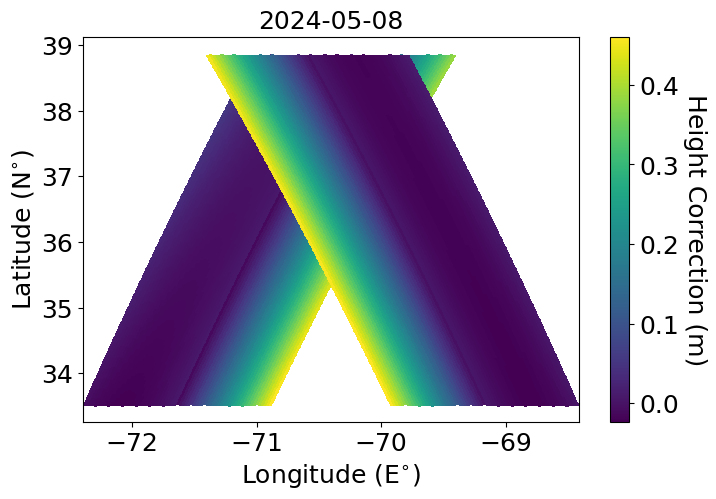

In [15]:
plt.clf()

fig,ax=plt.subplots(figsize=(8,5))
plot = ax.pcolormesh(ds1_masked.longitude-360,ds1_masked.latitude,ds1_masked.height_cor_xover)
plot = ax.pcolormesh(ds2_masked.longitude-360,ds2_masked.latitude,ds2_masked.height_cor_xover)

cbar = plt.colorbar(plot,ax=ax)

cbar.set_label('Height Correction (m)', rotation=270, labelpad=20)

ax.set_ylabel('Latitude (N$^{\circ}$)')
ax.set_xlabel('Longitude (E$^{\circ}$)')
ax.set_title('%s-%s-%s'%(date_requested[0:4],date_requested[4:6],date_requested[6:8]))

plt.show()

SSHA Karin 2 is the best quality to show the eddy

<Figure size 640x480 with 0 Axes>

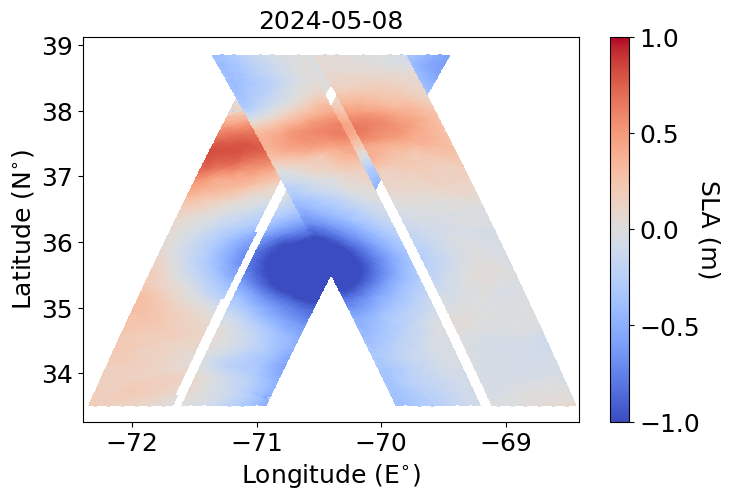

In [16]:
plt.clf()

fig,ax=plt.subplots(figsize=(8,5))
plot = ax.pcolormesh(ds1_masked.longitude-360,ds1_masked.latitude,ds1_masked.ssha_karin_2,cmap='coolwarm',vmin=-1,vmax=1)
plot = ax.pcolormesh(ds2_masked.longitude-360,ds2_masked.latitude,ds2_masked.ssha_karin_2,cmap='coolwarm',vmin=-1,vmax=1)

#plot = ax.pcolormesh(ds2_masked.longitude-360,ds2_masked.latitude,np.add(ds2_masked.ssha_karin_2,ds2_masked.height_cor_xover),cmap='coolwarm',vmin=-1,vmax=1)
cbar = plt.colorbar(plot,ax=ax)

cbar.set_label('SLA (m)', rotation=270, labelpad=15)

ax.set_ylabel('Latitude (N$^{\circ}$)')
ax.set_xlabel('Longitude (E$^{\circ}$)')
ax.set_title('%s-%s-%s'%(date_requested[0:4],date_requested[4:6],date_requested[6:8]))

plt.show()

Plot overlap

<Figure size 640x480 with 0 Axes>

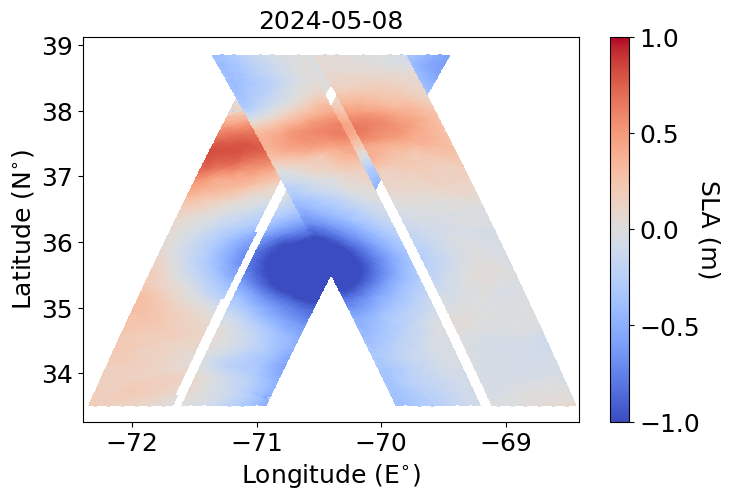

In [17]:
plt.clf()

fig,ax=plt.subplots(figsize=(8,5))
plot = ax.pcolormesh(ds1_masked.longitude-360,ds1_masked.latitude,ds1_masked.ssha_karin_2,cmap='coolwarm',vmin=-1,vmax=1)
plot = ax.pcolormesh(ds2_masked.longitude-360,ds2_masked.latitude,ds2_masked.ssha_karin_2,cmap='coolwarm',vmin=-1,vmax=1)

#plot = ax.pcolormesh(ds2_masked.longitude-360,ds2_masked.latitude,np.add(ds2_masked.ssha_karin_2,ds2_masked.height_cor_xover),cmap='coolwarm',vmin=-1,vmax=1)
cbar = plt.colorbar(plot,ax=ax)

cbar.set_label('SLA (m)', rotation=270, labelpad=15)

ax.set_ylabel('Latitude (N$^{\circ}$)')
ax.set_xlabel('Longitude (E$^{\circ}$)')
ax.set_title('%s-%s-%s'%(date_requested[0:4],date_requested[4:6],date_requested[6:8]))

plt.show()

Regrid SWOT data to regular grid. Need to do this before taking spatial gradients for velocity calculations.

In [18]:
xv = np.arange(lonmin+360, lonmax+360, 0.036)
yv = np.arange(latmin,latmax, 0.036)
grid_x, grid_y = np.meshgrid(xv, yv)
ssh=ds1_masked.ssha_karin_2+ds1_masked.height_cor_xover
lat=ds1_masked.latitude
lon=ds1_masked.longitude
grid_ssh1 = griddata((lon.values.ravel(),lat.values.ravel()), ssh.values.ravel(), (grid_x, grid_y), method='linear')
ssh=ds2_masked.ssha_karin_2+ds2_masked.height_cor_xover
lat=ds2_masked.latitude
lon=ds2_masked.longitude
grid_ssh2 = griddata((lon.values.ravel(),lat.values.ravel()), ssh.values.ravel(), (grid_x, grid_y), method='linear')

Plot regridded SSH

<Figure size 640x480 with 0 Axes>

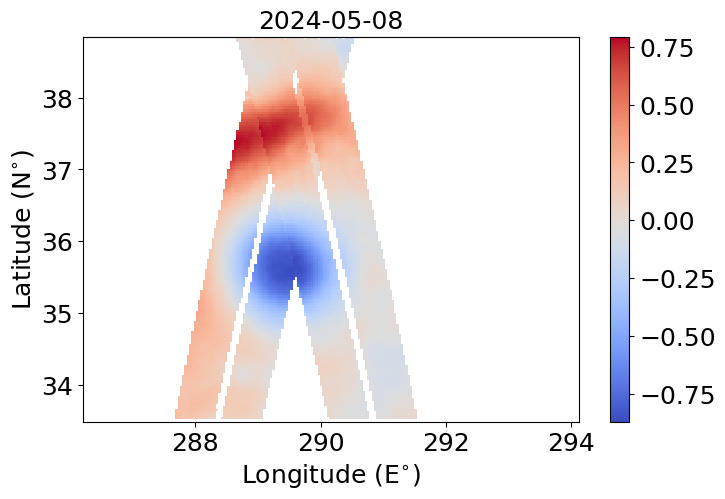

In [19]:
plt.clf()

fig,ax=plt.subplots(figsize=(8,5))
plot = ax.pcolormesh(grid_x,grid_y,grid_ssh1,cmap='coolwarm')
plot = ax.pcolormesh(grid_x,grid_y,grid_ssh2,cmap='coolwarm')
cbar = plt.colorbar(plot,ax=ax)

# cbar.set_label('dsdx', rotation=270, labelpad=15)

ax.set_ylabel('Latitude (N$^{\circ}$)')
ax.set_xlabel('Longitude (E$^{\circ}$)')
ax.set_title('%s-%s-%s'%(date_requested[0:4],date_requested[4:6],date_requested[6:8]))

plt.show()

In [20]:
def compute_geos_current(ssh,lat):
    """
    ssh: (m) Make sure this is first corrected with height_cor_xover from L2 data! 
    lat: degrees N
    """
    
    omega = 7.2921159e-05  # angular velocity of the Earth [rad/s]
    fc = 2*omega*np.sin(lat*np.pi/180.)
        
    # avoid zero near equator, bound fc by min val as 1.e-8
    f_coriolis = np.sign(fc)*np.maximum(np.abs(fc), 1.e-8)
    
    dx,dy = 4000,4000 # m i changed it to 4000 to match res? need to double check
    gravity = 9.81

    dsdy,dsdx=np.array(np.gradient(ssh, dx, edge_order=1))
    vg = (gravity/np.array(f_coriolis))*dsdx
    ug = -(gravity/np.array(f_coriolis))*dsdy
    geos_current = np.sqrt(ug**2 + vg**2)
    
    return ug,vg,geos_current

Compute geostrophic currents

In [21]:
#Calculate
ug1,vg1,geos_current1 = compute_geos_current(grid_ssh1,grid_y)
ug2,vg2,geos_current2 = compute_geos_current(grid_ssh2,grid_y)

<Figure size 640x480 with 0 Axes>

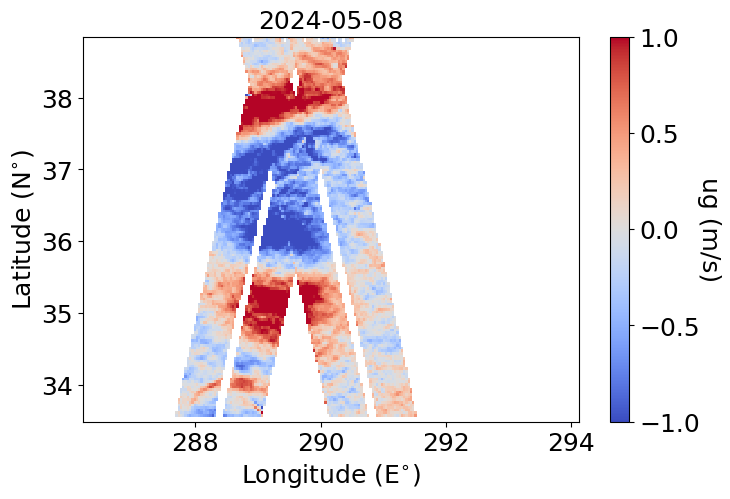

<Figure size 640x480 with 0 Axes>

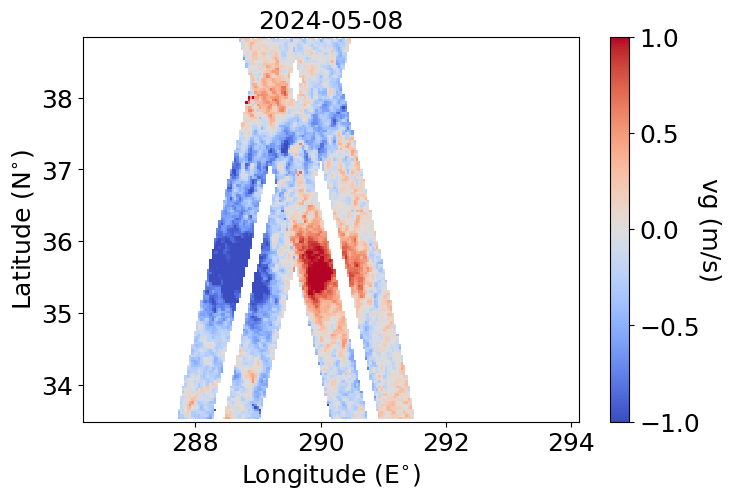

In [22]:
plt.clf()

fig,ax=plt.subplots(figsize=(8,5))
plot = ax.pcolormesh(grid_x,grid_y,ug1,cmap='coolwarm',vmin=-1,vmax=1)
plot = ax.pcolormesh(grid_x,grid_y,ug2,cmap='coolwarm',vmin=-1,vmax=1)
cbar = plt.colorbar(plot,ax=ax)

cbar.set_label('ug (m/s)', rotation=270, labelpad=15)

ax.set_ylabel('Latitude (N$^{\circ}$)')
ax.set_xlabel('Longitude (E$^{\circ}$)')
ax.set_title('%s-%s-%s'%(date_requested[0:4],date_requested[4:6],date_requested[6:8]))

plt.show()

plt.clf()

fig,ax=plt.subplots(figsize=(8,5))
plot = ax.pcolormesh(grid_x,grid_y,vg1,cmap='coolwarm',vmin=-1,vmax=1)
plot = ax.pcolormesh(grid_x,grid_y,vg2,cmap='coolwarm',vmin=-1,vmax=1)

cbar = plt.colorbar(plot,ax=ax)

cbar.set_label('vg (m/s)', rotation=270, labelpad=15)

ax.set_ylabel('Latitude (N$^{\circ}$)')
ax.set_xlabel('Longitude (E$^{\circ}$)')
ax.set_title('%s-%s-%s'%(date_requested[0:4],date_requested[4:6],date_requested[6:8]))

plt.show()

<Figure size 640x480 with 0 Axes>

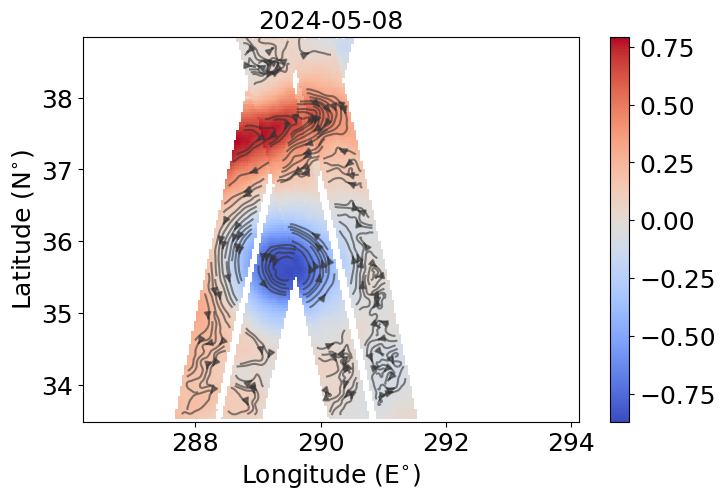

In [23]:
plt.clf()

fig,ax=plt.subplots(figsize=(8,5))
plot = ax.pcolormesh(grid_x,grid_y,grid_ssh1,cmap='coolwarm')
plot = ax.pcolormesh(grid_x,grid_y,grid_ssh2,cmap='coolwarm')
cbar = plt.colorbar(plot,ax=ax)
plt.streamplot(grid_x,grid_y,ug1,vg1, density = 5, color = (0.2,0.2,0.2,0.6))
plt.streamplot(grid_x,grid_y,ug2,vg2, density = 5, color = (0.2,0.2,0.2,0.6))

ax.set_ylabel('Latitude (N$^{\circ}$)')
ax.set_xlabel('Longitude (E$^{\circ}$)')
ax.set_title('%s-%s-%s'%(date_requested[0:4],date_requested[4:6],date_requested[6:8]))

plt.show()

### Load eddy data from AVISO

Using these contours to plot contour on top of chl & define in versus out of the eddy.

In [24]:
def get_eddy_by_ID_date(ds,eddy_date):
    """
    ds: netCDF AVISO format
    track_id: id of eddy to extract
    eddy_date: date in format 'YYYY-MM-DD'

    Returns contour lons, contour lats, center lon, center lat
    """
    try:
        ind = np.where(ds.time == np.datetime64(eddy_date))[0][0]
        contour_lons = np.array(ds.effective_contour_longitude[ind])
        contour_lats = np.array(ds.effective_contour_latitude[ind])
    except:
        print('No eddy data available with that request ... :(')        
    
    return contour_lons,contour_lats,ds.longitude[ind],ds.latitude[ind]

In [25]:
contour_lons,contour_lats,center_lon,center_lat = get_eddy_by_ID_date(aviso_ds,pacedate)

### Add in low-res altimeter data (OSCAR Velocity)

In [31]:
results = earthaccess.search_datasets(keyword="oscar")
for item in results[:3]: # subsetted to show the first couple of results because this is erroring for some reason
    summary = item.summary()
    print(summary["short-name"])

OSCAR_L4_OC_NRT_V2.0
OSCAR_L4_OC_FINAL_V2.0
OSCAR_L4_OC_INTERIM_V2.0


In [32]:
bbox = (lonmin, latmin, lonmax, latmax) # lonW, latS, lonE, latN
results = earthaccess.search_data(
        short_name="OSCAR_L4_OC_INTERIM_V2.0",
        bounding_box=bbox,
        temporal=(tmin,tmax))
    
print("Number of swaths: " + str(len(results))) # not daily files, so will likely be more than # of days
oscar_paths = earthaccess.open(results) # is there a way to choose a subset of variables here?

Number of swaths: 223


QUEUEING TASKS | :   0%|          | 0/223 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/223 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/223 [00:00<?, ?it/s]

In [33]:
dates_available = []
for i in oscar_paths:
    today = str(i).split('.')[-2].split('_')[-1]
    if today not in dates_available:
        dates_available.append(today)
print(dates_available)

['20231214', '20231215', '20231216', '20231217', '20231218', '20231219', '20231220', '20231221', '20231222', '20231223', '20231224', '20231225', '20231226', '20231227', '20231228', '20231229', '20231230', '20231231', '20240101', '20240102', '20240103', '20240104', '20240105', '20240106', '20240107', '20240108', '20240109', '20240110', '20240111', '20240112', '20240113', '20240114', '20240115', '20240116', '20240117', '20240118', '20240119', '20240120', '20240121', '20240122', '20240123', '20240124', '20240125', '20240126', '20240127', '20240128', '20240129', '20240130', '20240131', '20240201', '20240202', '20240203', '20240204', '20240205', '20240206', '20240207', '20240208', '20240209', '20240210', '20240211', '20240212', '20240213', '20240214', '20240215', '20240216', '20240217', '20240218', '20240219', '20240220', '20240221', '20240222', '20240223', '20240224', '20240225', '20240226', '20240227', '20240228', '20240229', '20240301', '20240302', '20240303', '20240304', '20240305', '20

In [38]:
ind = 0 
for i in oscar_paths:
    today = str(i).split('.')[-2].split('_')[-1]
    if date_requested == today:
        print(ind)
        sel=ind
    ind += 1

146


In [40]:
print(oscar_paths[sel])

<File-like object S3FileSystem, podaac-ops-cumulus-protected/OSCAR_L4_OC_INTERIM_V2.0/oscar_currents_interim_20240508.nc>


In [41]:
oscar_ds = xr.open_dataset(oscar_paths[sel])
oscar_ds = oscar_ds.transpose("time", "latitude", "longitude") # oscar reads in stupid, so just do this line.. trust me ;)
oscar_ds

<xarray.Dataset> Size: 33MB
Dimensions:  (latitude: 719, longitude: 1440, time: 1)
Coordinates:
    lat      (latitude) float64 6kB ...
    lon      (longitude) float64 12kB ...
  * time     (time) object 8B 2024-05-08 00:00:00
Dimensions without coordinates: latitude, longitude
Data variables:
    u        (time, latitude, longitude) float64 8MB ...
    v        (time, latitude, longitude) float64 8MB ...
    ug       (time, latitude, longitude) float64 8MB ...
    vg       (time, latitude, longitude) float64 8MB ...
Attributes: (12/36)
    title:                      Ocean Surface Current Analyses Real-time (OSC...
    summary:                    Global, daily, 0.25 degree geostrophic and to...
    keywords:                   ocean currents,ocean circulation,surface curr...
    Conventions:                CF-1.8 Standard Names v77, ACDD-1.3, netcdf 4...
    id:                         OSCAR_L4_OC_INTERIM_V2.0
    history:                    OSCAR 0.25 degree daily version 2.0 replaces ...
    ...                         ...
    geospatial_lon_max:         359.75
    geospatial_lon_units:       degrees_east
    geospatial_lon_resolution:  0.25 degree
    time_coverage_start:        2024-05-08T00:00:00
    time_coverage_end:          2024-05-08T23:59:59
    date_created:               2024-07-08

In [42]:
def crop_oscar_by_lat_lon(ds,latmin,latmax,lonmin,lonmax):
    mask = (ds.lat >= latmin) & (ds.lat <= latmax) & (ds.lon >= lonmin+360) & (ds.lon <= lonmax+360)
    ds_masked = ds.where(mask, drop=True)
    return ds_masked

In [43]:
oscar_ds_masked = crop_oscar_by_lat_lon(oscar_ds,latmin,latmax,lonmin,lonmax)
oscar_ds_masked

<xarray.Dataset> Size: 22kB
Dimensions:  (time: 1, latitude: 21, longitude: 32)
Coordinates:
    lat      (latitude) float64 168B 33.75 34.0 34.25 34.5 ... 38.25 38.5 38.75
    lon      (longitude) float64 256B 286.2 286.5 286.8 ... 293.5 293.8 294.0
  * time     (time) object 8B 2024-05-08 00:00:00
Dimensions without coordinates: latitude, longitude
Data variables:
    u        (time, latitude, longitude) float64 5kB 0.1406 0.2332 ... 0.9533
    v        (time, latitude, longitude) float64 5kB -0.395 -0.426 ... -0.105
    ug       (time, latitude, longitude) float64 5kB 0.09752 0.1885 ... 1.009
    vg       (time, latitude, longitude) float64 5kB -0.3588 -0.3934 ... -0.1031
Attributes: (12/36)
    title:                      Ocean Surface Current Analyses Real-time (OSC...
    summary:                    Global, daily, 0.25 degree geostrophic and to...
    keywords:                   ocean currents,ocean circulation,surface curr...
    Conventions:                CF-1.8 Standard Names v77, ACDD-1.3, netcdf 4...
    id:                         OSCAR_L4_OC_INTERIM_V2.0
    history:                    OSCAR 0.25 degree daily version 2.0 replaces ...
    ...                         ...
    geospatial_lon_max:         359.75
    geospatial_lon_units:       degrees_east
    geospatial_lon_resolution:  0.25 degree
    time_coverage_start:        2024-05-08T00:00:00
    time_coverage_end:          2024-05-08T23:59:59
    date_created:               2024-07-08

Each of the layers could be commented out as preferred (as in the presentation)

<Figure size 640x480 with 0 Axes>

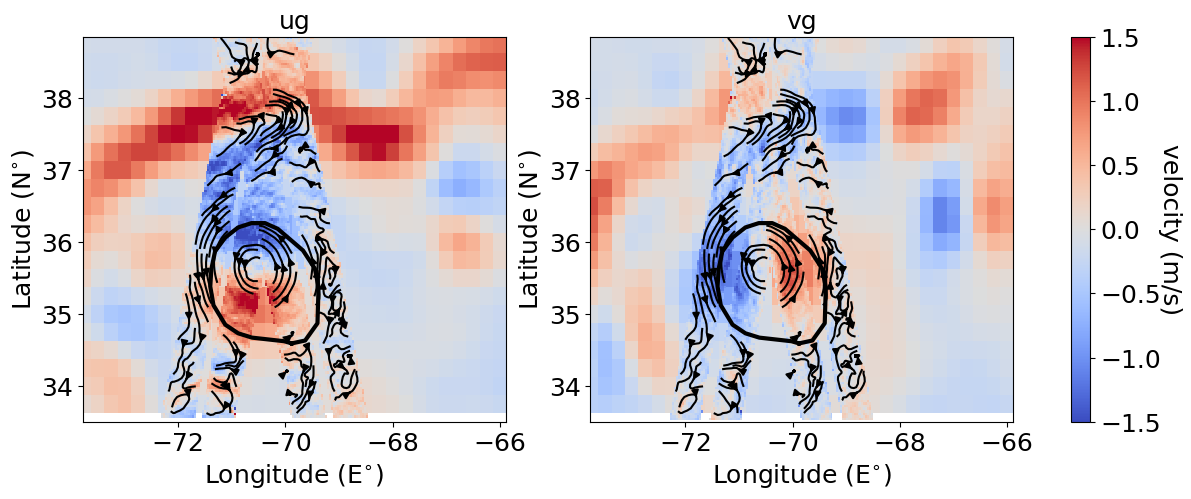

In [66]:
plt.clf()

magnitude = 1.5

fig,ax=plt.subplots(1,2,figsize=(15,5))

# LOW RES UG VELOCITY
plot = ax[0].pcolormesh(oscar_ds_masked.lon-360,oscar_ds_masked.lat,oscar_ds_masked.ug[0],cmap='coolwarm',vmin=-magnitude,vmax=magnitude)

# SWOT SWATHS OF VELOCITY
ax[0].pcolormesh(grid_x-360,grid_y,ug1,cmap='coolwarm',vmin=-magnitude,vmax=magnitude)
ax[0].pcolormesh(grid_x-360,grid_y,ug2,cmap='coolwarm',vmin=-magnitude,vmax=magnitude)

# STREAMLINES FROM SWOT
ax[0].streamplot(grid_x-360,grid_y,ug1,vg1, density = 3, color = 'k')
ax[0].streamplot(grid_x-360,grid_y,ug2,vg2, density = 3, color = 'k')

# EDDY CONTOUR
ax[0].plot(contour_lons-360,contour_lats,zorder=100,c='k',linewidth=3)

# PARAMS 
cbar = plt.colorbar(plot,ax=ax)
cbar.set_label('velocity (m/s)', rotation=270, labelpad=15)

# LOW RES VG VELOCITY
plot = ax[1].pcolormesh(oscar_ds_masked.lon-360,oscar_ds_masked.lat,oscar_ds_masked.vg[0],cmap='coolwarm',vmin=-magnitude,vmax=magnitude)

# SWOT SWATHS OF VELOCITY
ax[1].pcolormesh(grid_x-360,grid_y,vg1,cmap='coolwarm',vmin=-magnitude,vmax=magnitude)
ax[1].pcolormesh(grid_x-360,grid_y,vg2,cmap='coolwarm',vmin=-magnitude,vmax=magnitude)

# STREAMLINES FROM SWOT
ax[1].streamplot(grid_x-360,grid_y,ug1,vg1, density = 3, color = 'k')
ax[1].streamplot(grid_x-360,grid_y,ug2,vg2, density = 3, color = 'k')

# EDDY CONTOUR
ax[1].plot(contour_lons-360,contour_lats,zorder=100,c='k',linewidth=3)

# PARAMS 
# cbar = plt.colorbar(plot,ax=ax)
# cbar.set_label('vg (m/s)', rotation=270, labelpad=15)

ax[0].set_title('ug')
ax[1].set_title('vg')

for j in [0,1]:
    # ax[j].set_title('%s-%s-%s'%(date_requested[0:4],date_requested[4:6],date_requested[6:8]))
    ax[0].set_title('ug')
    ax[1].set_title('vg')
    ax[j].set_ylabel('Latitude (N$^{\circ}$)')
    ax[j].set_xlabel('Longitude (E$^{\circ}$)')
    ax[j].set_xlim([lonmin,lonmax])
    ax[j].set_ylim([latmin,latmax ])

plt.show()

In [56]:
### Now, working with low-res altimeter data

In [45]:
def dimension_edges(dim_array):
    adjustment = float(dim_array[1]-dim_array[0])/2
    adjusted_array = [float(i)-adjustment for i in dim_array]
    adjusted_array.append(dim_array[-1]+adjustment)
    return np.array(adjusted_array)

(33.5026969909668, 38.84738540649414)

<Figure size 640x480 with 0 Axes>

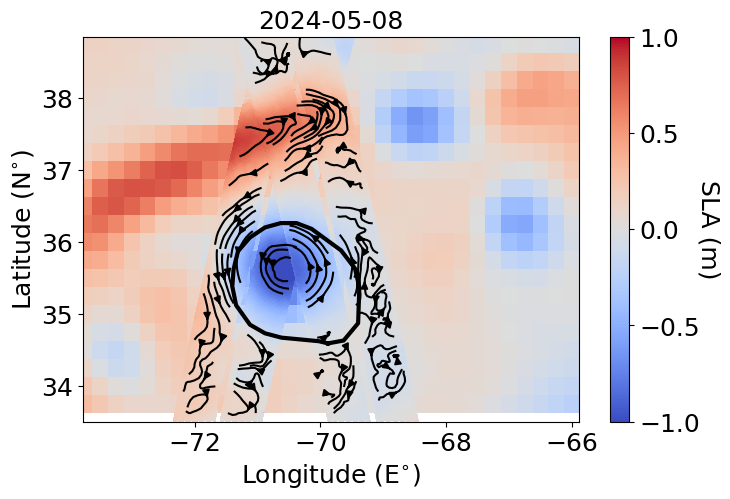

In [53]:
plt.clf()
fig,ax=plt.subplots(figsize=(8,5))

# Low res SLA
magnitude=1 # SLA range (m)

#Need to convert from lat/lon centers to edges to align the plot appropriately (see example above for a different options with lon_bnds/lat_bnds)
CMEMS_lon_edges = dimension_edges(CMEMS_day.longitude)
CMEMS_lat_edges = dimension_edges(CMEMS_day.latitude)
CMEMS_lon_inds = np.where((CMEMS_lon_edges >= lonmin) & (CMEMS_lon_edges <= lonmax))
CMEMS_lat_inds = np.where((CMEMS_lat_edges >= latmin) & (CMEMS_lat_edges <= latmax))

plot = ax.pcolormesh(CMEMS_lon_edges[CMEMS_lon_inds], CMEMS_lat_edges[CMEMS_lat_inds],CMEMS_day.sla[0,CMEMS_lat_inds[0],CMEMS_lon_inds[0]],
                     cmap='coolwarm',vmin=-magnitude,vmax=magnitude,shading='nearest')

#ax.grid(c='k')

# SWOT SSHA; not sure how to adjust this grid appropriately 
plot = ax.pcolormesh(ds1_masked.longitude-360,ds1_masked.latitude,np.add(ds1_masked.ssha_karin_2,ds1_masked.height_cor_xover),cmap='coolwarm',vmin=-magnitude,vmax=magnitude)
plot = ax.pcolormesh(ds2_masked.longitude-360,ds2_masked.latitude,np.add(ds2_masked.ssha_karin_2,ds2_masked.height_cor_xover),cmap='coolwarm',vmin=-magnitude,vmax=magnitude)


# STREAMLINES FROM SWOT
ax.streamplot(grid_x-360,grid_y,ug1,vg1, density = 3, color = 'k')
ax.streamplot(grid_x-360,grid_y,ug2,vg2, density = 3, color = 'k')

# EDDY CONTOUR
ax.plot(contour_lons-360,contour_lats,zorder=100,c='k',linewidth=3)
#ax.scatter(center_lon-360,center_lat,c='k')


cbar = plt.colorbar(plot,ax=ax)
cbar.set_label('SLA (m)', rotation=270, labelpad=15)

ax.set_ylabel('Latitude (N$^{\circ}$)')
ax.set_xlabel('Longitude (E$^{\circ}$)')
ax.set_title('%s-%s-%s'%(date_requested[0:4],date_requested[4:6],date_requested[6:8]))

ax.set_xlim([lonmin,lonmax])
ax.set_ylim([latmin,latmax ])

#plt.savefig('Edward_SLA_20240508.png',dpi=350,bbox_inches='tight')
#plt.show()

NOTE: I realized we don't have to calculate the "edges" for plotting with pcolormesh, as they're in the lon_bnds and lat_bnds variables

In [48]:
CMEMS_day.lon_bnds[:,0].values # western edges of pixels

array([-180.  , -179.75, -179.5 , ...,  179.25,  179.5 ,  179.75],
      dtype=float32)

In [49]:
CMEMS_day.lon_bnds[:,1].values # eastern edges of pixels

array([-179.75, -179.5 , -179.25, ...,  179.5 ,  179.75,  180.  ],
      dtype=float32)

In [50]:
CMEMS_day.lat_bnds[:,0].values[0:10] # northern edges of pixels

array([-90.  , -89.75, -89.5 , -89.25, -89.  , -88.75, -88.5 , -88.25,
       -88.  , -87.75], dtype=float32)

In [51]:
CMEMS_day.lat_bnds[:,1].values[0:10] # southern edges of pixels

array([-89.75, -89.5 , -89.25, -89.  , -88.75, -88.5 , -88.25, -88.  ,
       -87.75, -87.5 ], dtype=float32)

### Eddy-centered fig

Defining plot bounds to be centered on the eddy

In [ ]:
print(lonmin)
print(lonmax)
print(latmin)
print(latmax)

(33.5026969909668, 38.84738540649414)

<Figure size 640x480 with 0 Axes>

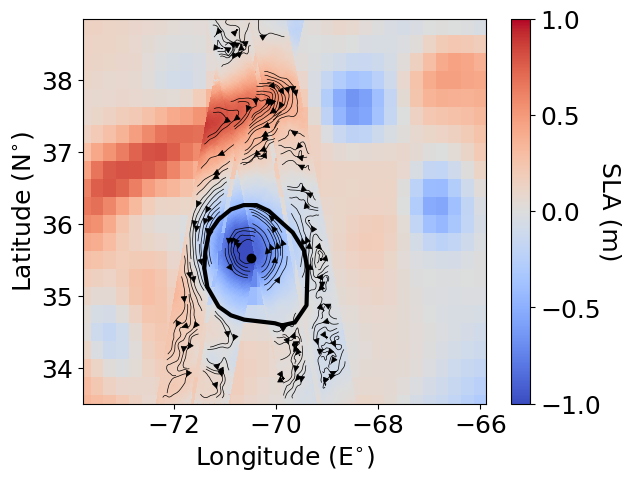

In [54]:
plt.clf()
fig,ax=plt.subplots(figsize=(6.5,5))

# Low res SLA
magnitude=1 # SLA range (m)

# get cropping indices based on the cell centers
CMEMS_lon_inds = list(np.where((CMEMS_day.longitude >= lonmin) & (CMEMS_day.longitude <= lonmax))[0])
CMEMS_lat_inds = list(np.where((CMEMS_day.latitude >= latmin) & (CMEMS_day.latitude <= latmax))[0])

# add last value to be centered based on python indexing
CMEMS_lon_inds.append(CMEMS_lon_inds[-1]+1)
CMEMS_lat_inds.append(CMEMS_lat_inds[-1]+1)

# pcolormesh expects the cell edge coordinates, not the center coords; using the western & northern bounds
plot = ax.pcolormesh(CMEMS_day.lon_bnds[:,0].values[CMEMS_lon_inds[0]:CMEMS_lon_inds[-1]+1], 
                     CMEMS_day.lat_bnds[:,0].values[CMEMS_lat_inds[0]:CMEMS_lat_inds[-1]+1],
                     CMEMS_day.sla[0,CMEMS_lat_inds,CMEMS_lon_inds],
                     cmap='coolwarm',vmin=-magnitude,vmax=magnitude,shading='nearest')
#ax.grid(c='k')

# SWOT SSHA; not sure how to adjust this grid appropriately 
plot = ax.pcolormesh(ds1_masked.longitude-360,ds1_masked.latitude,np.add(ds1_masked.ssha_karin_2,ds1_masked.height_cor_xover),cmap='coolwarm',vmin=-magnitude,vmax=magnitude)
plot = ax.pcolormesh(ds2_masked.longitude-360,ds2_masked.latitude,np.add(ds2_masked.ssha_karin_2,ds2_masked.height_cor_xover),cmap='coolwarm',vmin=-magnitude,vmax=magnitude)

# STREAMLINES FROM SWOT
ax.streamplot(grid_x-360,grid_y,ug1,vg1, density = 5, color = 'k',linewidth=0.5)
ax.streamplot(grid_x-360,grid_y,ug2,vg2, density = 5, color = 'k',linewidth=0.5)

# EDDY CONTOUR
ax.plot(contour_lons-360,contour_lats,zorder=100,c='k',linewidth=3)
ax.scatter(center_lon-360,center_lat,c='k')

cbar = plt.colorbar(plot,ax=ax)
cbar.set_label('SLA (m)', rotation=270, labelpad=15)

ax.set_ylabel('Latitude (N$^{\circ}$)')
ax.set_xlabel('Longitude (E$^{\circ}$)')
#ax.set_title('%s-%s-%s'%(date_requested[0:4],date_requested[4:6],date_requested[6:8]))

ax.set_xlim([lonmin,lonmax])
ax.set_ylim([latmin,latmax])

#plt.savefig('Edward_SLA_20240508_low_res_gridded.png',dpi=350,bbox_inches='tight')
#plt.savefig('Edward_SLA_20240508_high_res_overlay.png',dpi=350,bbox_inches='tight')